In [4]:
from pathlib import Path
from typing import Union
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector

try:
    import tifffile
except ImportError:
    tifffile = None


# =============================================================================
# Image loading / writing
# =============================================================================

def load_gray_native(path: Union[str, Path]) -> np.ndarray:
    """
    Load a grayscale image without changing its stored bit depth.

    Returns:
        uint8 or uint16 image when possible
    """
    p = Path(path)

    img = cv2.imread(str(p), cv2.IMREAD_UNCHANGED)

    if img is None:
        if tifffile is None:
            raise IOError(
                f"Could not decode image with OpenCV, and tifffile is not installed: {p}"
            )
        img = tifffile.imread(str(p))

    img = np.asarray(img)

    if img.ndim == 3:
        if img.shape[2] == 1:
            img = img[:, :, 0]
        elif img.shape[2] == 4:
            img = cv2.cvtColor(img, cv2.COLOR_BGRA2GRAY)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    return img


def detect_storage_mode(img: np.ndarray) -> str:
    """
    Detect likely storage mode of the input image.

    Returns:
        '8bit'
        '12in16_shifted'   -> values are multiples of 16, typical Phantom-style 12-bit in uint16
        '12in16_lowrange'  -> uint16 but values stay in 0..4095
        '16bit'
    """
    if img.dtype == np.uint8:
        return "8bit"

    if img.dtype != np.uint16:
        raise ValueError(f"Unsupported dtype for detection: {img.dtype}")

    mx = int(img.max())

    if np.all((img & 15) == 0):
        return "12in16_shifted"

    if mx <= 4095:
        return "12in16_lowrange"

    return "16bit"


def storage_mode_info(mode: str):
    """
    Return nominal bit depth and nominal max for a storage mode.
    """
    if mode == "8bit":
        return 8, 255
    if mode == "12in16_shifted":
        return 12, 4095
    if mode == "12in16_lowrange":
        return 12, 4095
    if mode == "16bit":
        return 16, 65535
    raise ValueError(f"Unknown storage mode: {mode}")


def decode_to_nominal(img_native: np.ndarray, mode: str) -> np.ndarray:
    """
    Convert stored image data into nominal processing space.

    Examples:
    - 8-bit stays 0..255
    - 12in16_shifted becomes 0..4095 by shifting right 4
    - 12in16_lowrange stays 0..4095
    - 16bit stays 0..65535
    """
    if mode == "8bit":
        return img_native.astype(np.float32)

    if mode == "12in16_shifted":
        return (img_native.astype(np.uint16) >> 4).astype(np.float32)

    if mode == "12in16_lowrange":
        return img_native.astype(np.float32)

    if mode == "16bit":
        return img_native.astype(np.float32)

    raise ValueError(f"Unknown storage mode: {mode}")


def encode_from_nominal(img_nominal: np.ndarray, mode: str) -> np.ndarray:
    """
    Convert nominal-space data back into the same storage style as input.
    Useful if you want to save the crop in the same format style as the original.
    """
    nominal_bits, nominal_max = storage_mode_info(mode)
    arr = np.clip(np.round(img_nominal), 0, nominal_max)

    if mode == "8bit":
        return arr.astype(np.uint8)

    if mode == "12in16_shifted":
        return (arr.astype(np.uint16) << 4)

    if mode == "12in16_lowrange":
        return arr.astype(np.uint16)

    if mode == "16bit":
        return arr.astype(np.uint16)

    raise ValueError(f"Unknown storage mode: {mode}")


def load_gray_nominal(path: Union[str, Path]):
    """
    Load one image and return:
        nominal_image_float32, detected_storage_mode
    """
    native = load_gray_native(path)
    mode = detect_storage_mode(native)
    nominal = decode_to_nominal(native, mode)
    return nominal, mode


def write_image_same_storage(path: Union[str, Path], img_nominal: np.ndarray, mode: str):
    """
    Save an image using the same storage style as the input.
    """
    p = Path(path)
    p.parent.mkdir(parents=True, exist_ok=True)

    out = encode_from_nominal(img_nominal, mode)
    ok = cv2.imwrite(str(p), out)
    if not ok:
        raise IOError(f"Failed to write image: {p}")


def to_display_u8(img: np.ndarray) -> np.ndarray:
    """
    Convert any grayscale image to uint8 for display only.
    """
    arr = img.astype(np.float32)
    mn = float(arr.min())
    mx = float(arr.max())

    if mx - mn < 1e-12:
        return np.full(arr.shape, 128, dtype=np.uint8)

    arr = 255.0 * (arr - mn) / (mx - mn)
    return np.clip(arr, 0, 255).astype(np.uint8)


# =============================================================================
# Crop selection from known vertical calibration line
# =============================================================================

def _clip_crop_box_to_image(
    x: int,
    y: int,
    w: int,
    h: int,
    image_shape: tuple[int, int],
) -> tuple[int, int, int, int]:
    """
    Clip crop box to image bounds.
    """
    n_rows, n_cols = image_shape

    x0 = max(0, x)
    y0 = max(0, y)
    x1 = min(n_cols, x + w)
    y1 = min(n_rows, y + h)

    w_clipped = x1 - x0
    h_clipped = y1 - y0

    if w_clipped <= 0 or h_clipped <= 0:
        raise ValueError("Crop box is outside image bounds.")

    return x0, y0, w_clipped, h_clipped


def select_calibration_line_crop_region(
    image_path: Union[str, Path],
    *,
    known_line_height_inch: float = 0.5,
    vertical_padding_px: int = 5,
    horizontal_half_width_px: int = 12,
):
    """
    Draw a vertical line corresponding to a known physical height.

    The crop box is then created from that line:
        height = line height + 5 px above + 5 px below
        width  = 12 px left + line center + 12 px right

    Returns:
        crop_box: (x, y, w, h)
        crop_calibration: dict containing pixel-to-mm calibration info
    """
    p = Path(image_path)

    if p.is_dir():
        frames = _gather_frames(p)
        if not frames:
            raise ValueError(f"No images found in directory: {p}")
        image_path = frames[0]
    else:
        image_path = p

    img_nominal, _ = load_gray_nominal(image_path)
    img = to_display_u8(img_nominal)

    points = []
    temp_point = None

    win = "Draw 0.5 inch vertical calibration line"
    cv2.namedWindow(win, cv2.WINDOW_NORMAL)
    cv2.resizeWindow(win, 1200, 800)

    def redraw():
        display = cv2.cvtColor(img.copy(), cv2.COLOR_GRAY2BGR)

        if len(points) >= 1:
            cv2.circle(display, points[0], 4, (0, 255, 0), -1)

        if len(points) == 1 and temp_point is not None:
            cv2.line(display, points[0], temp_point, (0, 255, 255), 1)

        if len(points) == 2:
            p1, p2 = points
            cv2.circle(display, p2, 4, (0, 255, 0), -1)
            cv2.line(display, p1, p2, (0, 255, 0), 2)

            x_center = int(round(0.5 * (p1[0] + p2[0])))
            y_top = min(p1[1], p2[1])
            y_bottom = max(p1[1], p2[1])

            x = x_center - horizontal_half_width_px
            y = y_top - vertical_padding_px
            w = 2 * horizontal_half_width_px + 1
            h = (y_bottom - y_top) + 2 * vertical_padding_px + 1

            x, y, w, h = _clip_crop_box_to_image(x, y, w, h, img.shape)
            cv2.rectangle(display, (x, y), (x + w - 1, y + h - 1), (255, 0, 0), 2)

        cv2.imshow(win, display)

    def mouse_callback(event, x, y, flags, param):
        nonlocal temp_point

        if event == cv2.EVENT_MOUSEMOVE:
            temp_point = (x, y)
            redraw()

        elif event == cv2.EVENT_LBUTTONDOWN:
            if len(points) < 2:
                points.append((x, y))
            redraw()

    cv2.setMouseCallback(win, mouse_callback)

    print("Click the top and bottom of the 0.5 inch vertical line.")
    print("Press ENTER or SPACE when done.")
    print("Press r to reset.")
    print("Press ESC to cancel.")

    redraw()

    while True:
        key = cv2.waitKey(20) & 0xFF

        if key in [13, 32]:  # ENTER or SPACE
            if len(points) == 2:
                break

        elif key == ord("r"):
            points.clear()
            temp_point = None
            redraw()

        elif key == 27:  # ESC
            cv2.destroyAllWindows()
            raise ValueError("Calibration line selection cancelled.")

    cv2.destroyAllWindows()

    p1, p2 = points

    x_center = int(round(0.5 * (p1[0] + p2[0])))
    y_top = min(p1[1], p2[1])
    y_bottom = max(p1[1], p2[1])

    line_height_px = y_bottom - y_top

    if line_height_px <= 0:
        raise ValueError("Calibration line must have nonzero vertical height.")

    known_line_height_mm = known_line_height_inch * 25.4
    mm_per_px = known_line_height_mm / line_height_px

    x = x_center - horizontal_half_width_px
    y = y_top - vertical_padding_px
    w = 2 * horizontal_half_width_px + 1
    h = line_height_px + 2 * vertical_padding_px + 1

    crop_box = _clip_crop_box_to_image(x, y, w, h, img.shape)

    crop_calibration = {
        "line_p1": p1,
        "line_p2": p2,
        "line_y_top": y_top,
        "line_y_bottom": y_bottom,
        "line_center_y_px": 0.5 * (y_top + y_bottom),
        "line_height_px": line_height_px,
        "known_line_height_mm": known_line_height_mm,
        "mm_per_px": mm_per_px,
        "crop_box": crop_box,
    }

    print(f"Crop selected: x={crop_box[0]}, y={crop_box[1]}, w={crop_box[2]}, h={crop_box[3]}")
    print(f"Calibration line height: {line_height_px} px = {known_line_height_mm:.4f} mm")
    print(f"Scale: {mm_per_px:.6f} mm/px")

    return crop_box, crop_calibration

def crop_image(
    img: np.ndarray,
    crop_box: tuple[int, int, int, int] | None
) -> np.ndarray:
    """
    Crop image using (x, y, w, h).

    If crop_box is None, return the full image.
    """
    if crop_box is None:
        return img

    x, y, w, h = crop_box
    return img[y:y + h, x:x + w]


# =============================================================================
# Physical coordinate helpers
# =============================================================================

def make_vertical_mm_axis_from_calibration(
    n_rows: int,
    crop_box: tuple[int, int, int, int],
    crop_calibration: dict,
) -> np.ndarray:
    """
    Create vertical coordinate axis in mm using the drawn 0.5 inch line.

    Sign convention:
        positive y_mm = above the line center
        negative y_mm = below the line center

    Therefore, negative values appear at the bottom of the image.
    """
    _, crop_y0, _, _ = crop_box

    global_row_indices = crop_y0 + np.arange(n_rows)
    line_center_y_px = crop_calibration["line_center_y_px"]
    mm_per_px = crop_calibration["mm_per_px"]

    y_mm = (line_center_y_px - global_row_indices) * mm_per_px

    return y_mm


def make_vertical_mm_axis(n_rows: int, crop_height_mm: float = 12.7) -> np.ndarray:
    """
    Backup axis when no calibration line is available.

    Sign convention:
        top    = positive
        center = zero
        bottom = negative
    """
    half = crop_height_mm / 2.0
    return np.linspace(half, -half, n_rows)


def compute_deflection_angle(vertical_mm: np.ndarray, focal_length_mm: float = 20000.0) -> np.ndarray:
    """
    Compute deflection angle theta = r / f.

    Inputs:
        vertical_mm: vertical position in mm
        focal_length_mm: focal length in mm

    Output:
        theta in radians
    """
    return vertical_mm / focal_length_mm


# =============================================================================
# Plotting / analysis
# =============================================================================

TARGET_THETA_MRAD = 0.03169081573284781


def get_vertical_position_for_theta_mrad(
    theta_mrad: float,
    focal_length_mm: float,
) -> float:
    """
    Convert deflection angle in mrad back to vertical position in mm.

    theta_rad = y / f
    theta_mrad = 1000 * y / f

    Therefore:
        y_mm = theta_mrad * f_mm / 1000
    """
    return theta_mrad * focal_length_mm / 1000.0

def plot_cropped_image_with_physical_axis(
    crop_nominal: np.ndarray,
    y_mm: np.ndarray,
):
    """
    Plot cropped image with:
    - x axis in pixels
    - y axis in mm
    """
    n_rows, n_cols = crop_nominal.shape
    img_disp = to_display_u8(crop_nominal)

    extent = [0, n_cols - 1, y_mm[-1], y_mm[0]]

    plt.figure(figsize=(7, 6))
    plt.imshow(img_disp, cmap="gray", extent=extent, aspect="auto", origin="upper")
    plt.xlabel("Horizontal pixel index")
    plt.ylabel("Vertical position (mm)")
    plt.title("Cropped Calibration Lens Region")
    plt.colorbar(label="Display intensity, 8-bit scaled")
    plt.tight_layout()
    plt.show()


def extract_middle_vertical_slice(crop_nominal: np.ndarray):
    """
    Return the middle vertical slice from the cropped image.
    """
    _, n_cols = crop_nominal.shape
    center_col = n_cols // 2
    profile = crop_nominal[:, center_col].astype(np.float32)
    return center_col, profile


def extract_mean_vertical_profile(crop_nominal: np.ndarray):
    """
    Return the mean vertical intensity profile across the full crop width.

    This is usually better than only using the center column because it reduces noise.
    """
    profile = np.mean(crop_nominal.astype(np.float32), axis=1)
    return profile


def plot_intensity_vs_vertical_distance(
    crop_nominal: np.ndarray,
    y_mm: np.ndarray,
    nominal_max: float,
    *,
    use_width_average: bool = True,
):
    """
    Plot pixel intensity vs vertical position.

    If use_width_average=True, average across the crop width.
    Otherwise, use the middle column only.
    """
    center_col, center_profile = extract_middle_vertical_slice(crop_nominal)

    if use_width_average:
        profile = extract_mean_vertical_profile(crop_nominal)
        label = "Width-averaged intensity profile"
        title = "Pixel Intensity vs Vertical Position"
    else:
        profile = center_profile
        label = f"Middle column {center_col}"
        title = f"Middle Vertical Slice Intensity Profile, column {center_col}"

    plt.figure(figsize=(6, 5))
    plt.plot(y_mm, profile, label=label)
    plt.xlabel("Vertical position (mm)")
    plt.ylabel("Pixel intensity, nominal image units")
    plt.title(title)
    plt.ylim(0, nominal_max)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return y_mm, profile, center_col


def plot_deflection_angle_vs_vertical_distance(
    crop_nominal: np.ndarray,
    y_mm: np.ndarray,
    focal_length_mm: float = 20000.0,
    target_theta_mrad: float = TARGET_THETA_MRAD,
):
    """
    Plot deflection angle vs vertical position.

    Note:
    This angle is determined by geometric position r, not directly by intensity.
    """
    theta_rad = compute_deflection_angle(y_mm, focal_length_mm=focal_length_mm)
    theta_mrad = 1000.0 * theta_rad

    target_y_mm = get_vertical_position_for_theta_mrad(
        target_theta_mrad,
        focal_length_mm,
    )

    plt.figure(figsize=(6, 5))
    plt.plot(y_mm, theta_mrad, label="Deflection angle")

    plt.axhline(target_theta_mrad, linestyle="--", label=f"Max θ expected from plasma = {target_theta_mrad:.6f} mrad")
    plt.axvline(target_y_mm, linestyle="--", label=f"y = {target_y_mm:.6f} mm")
    plt.scatter([target_y_mm], [target_theta_mrad], zorder=5)

    plt.xlabel("Vertical position (mm)")
    plt.ylabel("Deflection angle (mrad)")
    plt.title("Deflection Angle vs Vertical Position")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return y_mm, theta_rad, theta_mrad, target_y_mm


def plot_deflection_angle_vs_pixel_intensity(
    crop_nominal: np.ndarray,
    y_mm: np.ndarray,
    nominal_max: float,
    focal_length_mm: float = 20000.0,
    target_theta_mrad: float = TARGET_THETA_MRAD,
    *,
    use_width_average: bool = True,
):
    """
    Plot deflection angle vs pixel intensity.

    Recommended interpretation:
        Each row gives one vertical position.
        Each vertical position gives one deflection angle.
        The image gives the intensity at that same row.

    So this is a parametric plot:
        x = intensity(y)
        y = theta(y)

    If use_width_average=True, intensity is averaged across the crop width.
    """
    center_col, center_profile = extract_middle_vertical_slice(crop_nominal)

    if use_width_average:
        intensity_profile = extract_mean_vertical_profile(crop_nominal)
        label = "Width-averaged profile"
    else:
        intensity_profile = center_profile
        label = f"Middle column {center_col}"

    theta_rad = compute_deflection_angle(y_mm, focal_length_mm=focal_length_mm)
    theta_mrad = 1000.0 * theta_rad

    # Interpolate intensity at the target deflection angle.
    # Sort because y_mm/theta_mrad may be decreasing from top to bottom.
    sort_idx = np.argsort(theta_mrad)
    theta_sorted = theta_mrad[sort_idx]
    intensity_sorted = intensity_profile[sort_idx]

    target_in_range = theta_sorted[0] <= target_theta_mrad <= theta_sorted[-1]

    if target_in_range:
        target_intensity = np.interp(
            target_theta_mrad,
            theta_sorted,
            intensity_sorted,
        )
    else:
        target_intensity = None

    plt.figure(figsize=(6, 5))
    plt.plot(intensity_profile, theta_mrad, label=label)

    plt.axhline(target_theta_mrad, linestyle="--", label=f"Max θ expected from plasma = {target_theta_mrad:.6f} mrad")

    if target_intensity is not None:
        plt.axvline(target_intensity, linestyle="--", label=f"I = {target_intensity:.2f}")
        plt.scatter([target_intensity], [target_theta_mrad], zorder=5)

    plt.xlabel("Pixel intensity, nominal image units")
    plt.ylabel("Deflection angle (mrad)")
    plt.title("Deflection Angle vs Pixel Intensity")
    plt.xlim(0, nominal_max)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return intensity_profile, theta_mrad, target_intensity


def overlay_middle_slice_on_crop(
    crop_nominal: np.ndarray,
    y_mm: np.ndarray,
):
    """
    Plot cropped image and mark the middle vertical slice.
    """
    n_rows, n_cols = crop_nominal.shape
    center_col, _ = extract_middle_vertical_slice(crop_nominal)

    img_disp = to_display_u8(crop_nominal)
    extent = [0, n_cols - 1, y_mm[-1], y_mm[0]]

    plt.figure(figsize=(7, 6))
    plt.imshow(img_disp, cmap="gray", extent=extent, aspect="auto", origin="upper")
    plt.axvline(center_col, linestyle="--")
    plt.xlabel("Horizontal pixel index")
    plt.ylabel("Vertical position (mm)")
    plt.title("Cropped Lens Region with Middle Vertical Slice")
    plt.colorbar(label="Display intensity, 8-bit scaled")
    plt.tight_layout()
    plt.show()


# =============================================================================
# Main analysis
# =============================================================================

def analyze_calibration_lens_frame(
    image_path: Union[str, Path],
    *,
    crop_box: tuple[int, int, int, int] | None = None,
    crop_calibration: dict | None = None,
    choose_crop_interactively: bool = True,
    known_line_height_inch: float = 0.5,
    focal_length_mm: float = 20000.0,
    save_cropped_path: Union[str, Path] | None = None,
    use_width_average: bool = False,
):
    """
    Full pipeline for one calibration lens frame.

    Steps:
    1. Load image with bit-depth-aware handling
    2. Draw a known 0.5 inch calibration line
    3. Create crop from that line
    4. Build flipped physical vertical axis
    5. Plot cropped image
    6. Plot intensity vs vertical position
    7. Plot deflection angle vs vertical position
    8. Plot deflection angle vs pixel intensity
    9. Optionally save cropped image using same storage style as input

    Returns:
        results dict
    """
    image_path = Path(image_path)

    img_nominal, mode = load_gray_nominal(image_path)
    nominal_bits, nominal_max = storage_mode_info(mode)

    print(f"Detected storage mode: {mode}")
    print(f"Nominal bit depth: {nominal_bits}")
    print(f"Nominal max value: {nominal_max}")
    print(f"Image shape: {img_nominal.shape}")
    print(f"Nominal min/max: {img_nominal.min()} / {img_nominal.max()}")

    if crop_box is None:
        if choose_crop_interactively:
            crop_box, crop_calibration = select_calibration_line_crop_region(
                image_path,
                known_line_height_inch=known_line_height_inch,
                vertical_padding_px=5,
                horizontal_half_width_px=12,
            )
        else:
            raise ValueError("Provide crop_box or set choose_crop_interactively=True")

    crop_nominal = crop_image(img_nominal, crop_box)

    if crop_calibration is not None:
        y_mm = make_vertical_mm_axis_from_calibration(
            crop_nominal.shape[0],
            crop_box,
            crop_calibration,
        )
    else:
        crop_height_mm = known_line_height_inch * 25.4
        y_mm = make_vertical_mm_axis(
            crop_nominal.shape[0],
            crop_height_mm=crop_height_mm,
        )

    if save_cropped_path is not None:
        write_image_same_storage(save_cropped_path, crop_nominal, mode)
        print(f"Cropped image saved to: {save_cropped_path}")

    overlay_middle_slice_on_crop(crop_nominal, y_mm)
    plot_cropped_image_with_physical_axis(crop_nominal, y_mm)

    y_mm_profile, intensity_profile, center_col = plot_intensity_vs_vertical_distance(
        crop_nominal,
        y_mm,
        nominal_max,
        use_width_average=use_width_average,
    )

    y_mm_angle, theta_rad, theta_mrad, target_y_mm = plot_deflection_angle_vs_vertical_distance(
        crop_nominal,
        y_mm,
        focal_length_mm=focal_length_mm,
        target_theta_mrad=TARGET_THETA_MRAD,
    )

    intensity_for_theta, theta_for_intensity, target_intensity = plot_deflection_angle_vs_pixel_intensity(
        crop_nominal,
        y_mm,
        nominal_max,
        focal_length_mm=focal_length_mm,
        target_theta_mrad=TARGET_THETA_MRAD,
        use_width_average=use_width_average,
    )

    results = {
        "storage_mode": mode,
        "nominal_bits": nominal_bits,
        "nominal_max": nominal_max,
        "crop_box": crop_box,
        "crop_calibration": crop_calibration,
        "crop_nominal": crop_nominal,
        "y_mm": y_mm,
        "center_col": center_col,
        "intensity_profile": intensity_profile,
        "theta_rad": theta_rad,
        "theta_mrad": theta_mrad,
        "target_theta_mrad": TARGET_THETA_MRAD,
        "target_y_mm": target_y_mm,
        "target_intensity": target_intensity,
        "focal_length_mm": focal_length_mm,
    }

    return results

Detected storage mode: 12in16_shifted
Nominal bit depth: 12
Nominal max value: 4095
Image shape: (64, 512)
Nominal min/max: 0.0 / 2959.0
Click the top and bottom of the 0.5 inch vertical line.
Press ENTER or SPACE when done.
Press r to reset.
Press ESC to cancel.
Crop selected: x=405, y=22, w=25, h=30
Calibration line height: 19 px = 12.7000 mm
Scale: 0.668421 mm/px


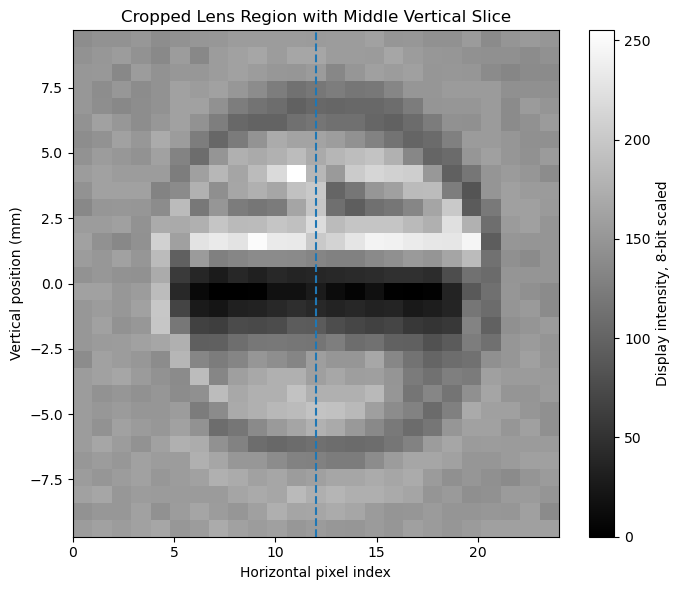

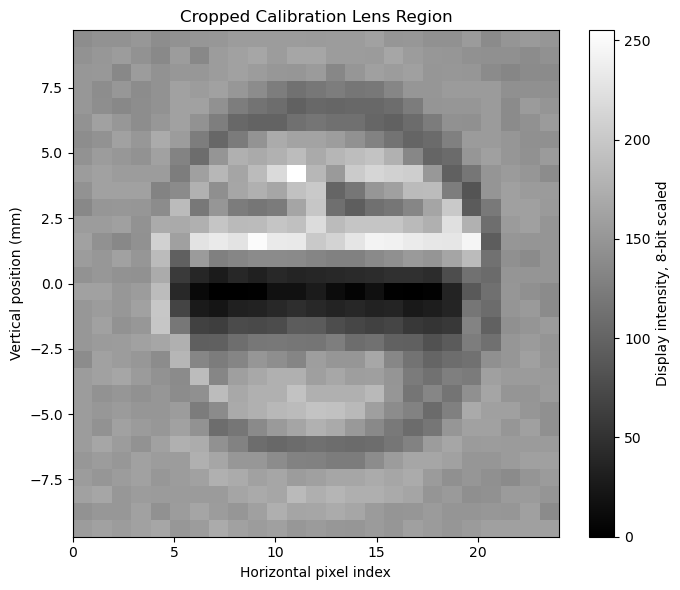

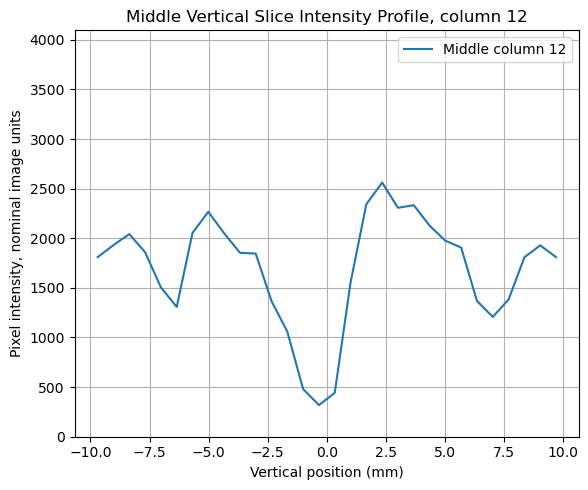

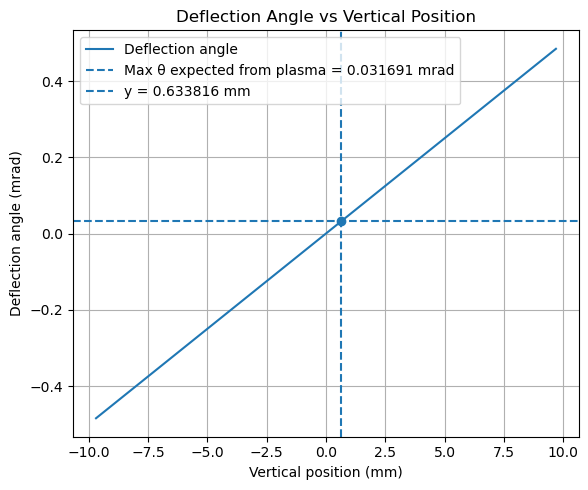

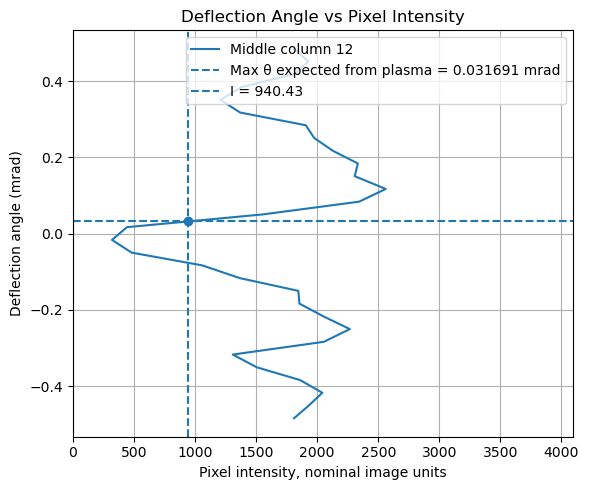

In [8]:
image_path = r"C:\Users\ahada\OneDrive\University of Washington\Z-Pinch Fusion\schlieren data\Schlieren data\260421\260421007 PROCESSED\260421007000_proc.tif"

results = analyze_calibration_lens_frame(
    image_path,
)